### Reading in Data, Basic Queries

In [1]:

import pandas as pd
import seaborn as sns
import plotly.express as px
pd.options.display.max_rows = 10

```
Post the following to the discussion board:

Attach your visualization.
Explain the method you used to create the visualization.
Share what library you used.
```

In [2]:
df = pd.read_csv("../data/gdp.csv")

In [3]:
df["gdp"] = df["GDP (constant 2010 US$)"] / 1_000_000_000

In [4]:
df.head()

,Entity,Code,Year,GDP (constant 2010 US$),gdp
0,Afghanistan,AFG,2002,8.013233e+09,8.013233
1,Afghanistan,AFG,2003,8.689884e+09,8.689884
2,Afghanistan,AFG,2004,8.781610e+09,8.781610
3,Afghanistan,AFG,2005,9.762979e+09,9.762979
4,Afghanistan,AFG,2006,1.030523e+10,10.305228


In [5]:
pop = pd.read_csv("../data/population.csv")
pop

,Entity,Code,Year,"Total population (Gapminder, HYDE & UN)"
0,Afghanistan,AFG,1800,3280000
1,Afghanistan,AFG,1801,3280000
2,Afghanistan,AFG,1802,3280000
3,Afghanistan,AFG,1803,3280000
4,Afghanistan,AFG,1804,3280000
...,...,...,...,...
46878,Zimbabwe,ZWE,2015,13815000
46879,Zimbabwe,ZWE,2016,14030000
46880,Zimbabwe,ZWE,2017,14237000
46881,Zimbabwe,ZWE,2018,14439000


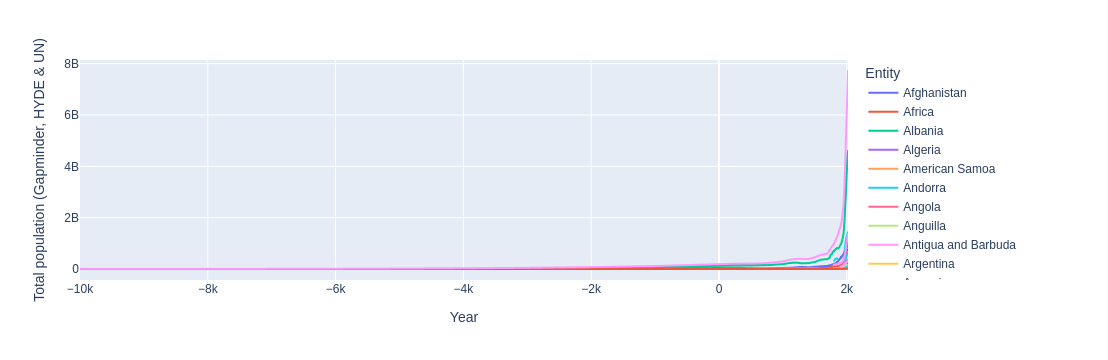

In [6]:
px.line(pop, x="Year", y="Total population (Gapminder, HYDE & UN)", color="Entity" )

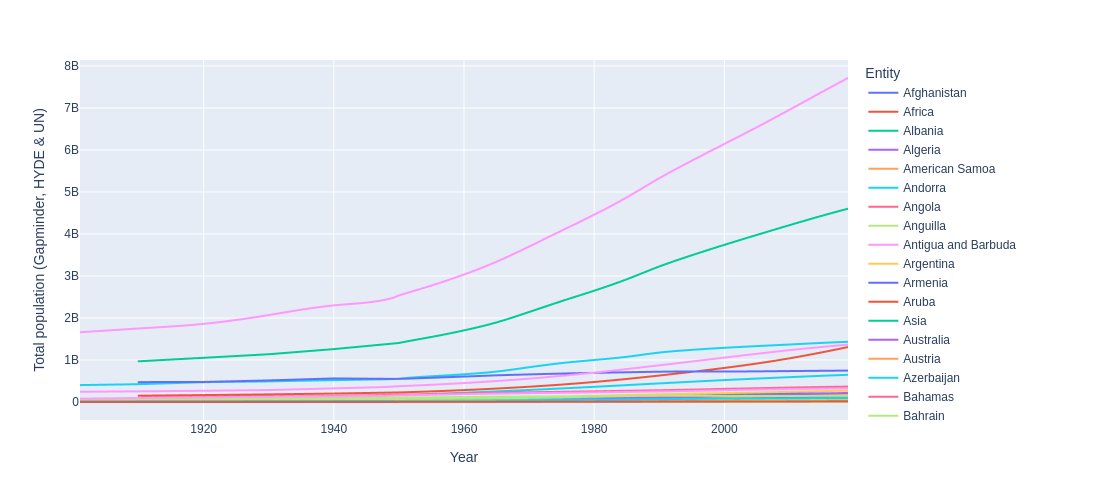

In [7]:
px.line(pop.query("Year > 1900"), x="Year", y="Total population (Gapminder, HYDE & UN)", color="Entity" , height=500)

In [8]:
pop = pop.rename(columns = {"Total population (Gapminder, HYDE & UN)" : "population"})

In [9]:
pop2017 = pop.query("Year== 2017")

In [10]:
gdp2017 = df.query("Year == 2017")


In [11]:
gdp = df

## Merge

In [12]:
gdp_and_pop_2017 = pd.merge(left=gdp2017, right=pop2017,on="Entity", how = "outer")
gdp_and_pop_2017

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population
0,Afghanistan,AFG,2017.0,2.196941e+10,21.969414,AFG,2017.0,3.629600e+07
1,Africa,NaN,NaN,NaN,NaN,NaN,2017.0,1.244222e+09
2,Albania,ALB,2017.0,1.398856e+10,13.988556,ALB,2017.0,2.884000e+06
3,Algeria,DZA,2017.0,1.993674e+11,199.367414,DZA,2017.0,4.138900e+07
4,American Samoa,NaN,NaN,NaN,NaN,ASM,2017.0,5.600000e+04
...,...,...,...,...,...,...,...,...
238,Western Sahara,NaN,NaN,NaN,NaN,ESH,2017.0,5.530000e+05
239,World,NaN,NaN,NaN,NaN,OWID_WRL,2017.0,7.547859e+09
240,Yemen,NaN,NaN,NaN,NaN,YEM,2017.0,2.783500e+07
241,Zambia,ZMB,2017.0,2.813940e+10,28.139397,ZMB,2017.0,1.685400e+07


#### GDP per Capita

In [13]:
# divide GDP by population
gdp_and_pop_2017["gdp_per_capita"] = gdp_and_pop_2017["GDP (constant 2010 US$)"] / gdp_and_pop_2017["population"]

In [14]:
gdp_and_pop_2017["gdp_per_capita"] 

0       605.284718
1              NaN
2      4850.400743
3      4816.917876
4              NaN
          ...     
238            NaN
239            NaN
240            NaN
241    1669.597527
242    1076.758501
Name: gdp_per_capita, Length: 243, dtype: float64

#### What happend with the table join?

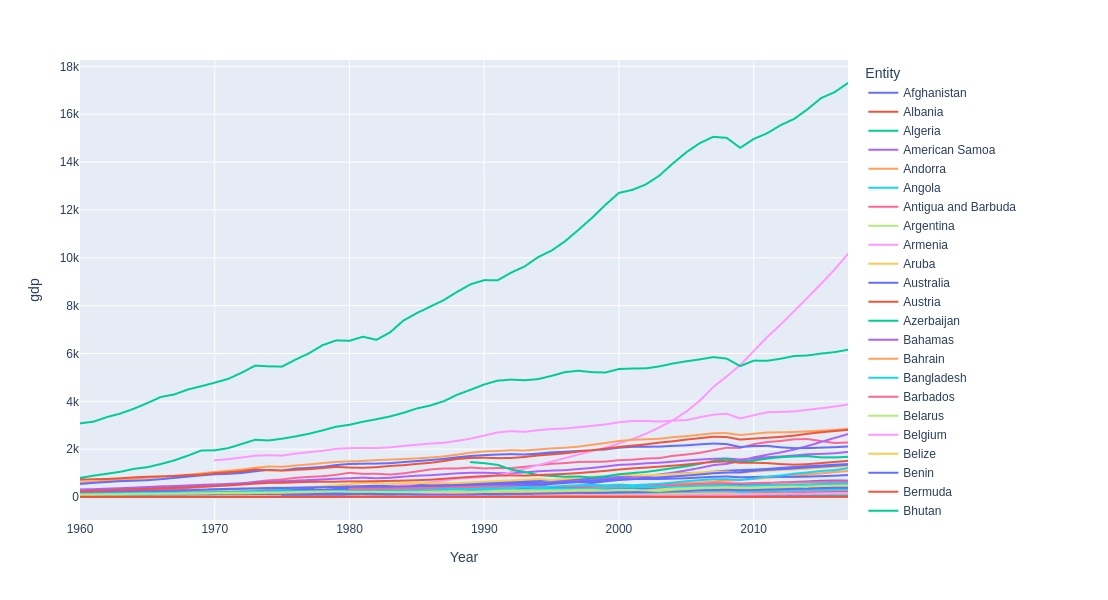

In [15]:
px.line(gdp, x="Year", y="gdp", color="Entity", height=600)

#### Joins
* outer - all
* inner - just matches
* left - all left and right matches
* right - all right and left matches

In [16]:
outer = pd.merge(left=gdp2017, right=pop2017,on="Entity", how = "outer")
outer

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population
0,Afghanistan,AFG,2017.0,2.196941e+10,21.969414,AFG,2017.0,3.629600e+07
1,Africa,NaN,NaN,NaN,NaN,NaN,2017.0,1.244222e+09
2,Albania,ALB,2017.0,1.398856e+10,13.988556,ALB,2017.0,2.884000e+06
3,Algeria,DZA,2017.0,1.993674e+11,199.367414,DZA,2017.0,4.138900e+07
4,American Samoa,NaN,NaN,NaN,NaN,ASM,2017.0,5.600000e+04
...,...,...,...,...,...,...,...,...
238,Western Sahara,NaN,NaN,NaN,NaN,ESH,2017.0,5.530000e+05
239,World,NaN,NaN,NaN,NaN,OWID_WRL,2017.0,7.547859e+09
240,Yemen,NaN,NaN,NaN,NaN,YEM,2017.0,2.783500e+07
241,Zambia,ZMB,2017.0,2.813940e+10,28.139397,ZMB,2017.0,1.685400e+07


In [17]:
left = pd.merge(left=gdp2017, right=pop2017,on="Entity", how = "left")
left

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population
0,Afghanistan,AFG,2017,2.196941e+10,21.969414,AFG,2017.0,36296000.0
1,Albania,ALB,2017,1.398856e+10,13.988556,ALB,2017.0,2884000.0
2,Algeria,DZA,2017,1.993674e+11,199.367414,DZA,2017.0,41389000.0
3,Andorra,AND,2017,3.382068e+09,3.382068,AND,2017.0,77000.0
4,Angola,AGO,2017,1.037860e+11,103.785984,AGO,2017.0,29817000.0
...,...,...,...,...,...,...,...,...
180,Uzbekistan,UZB,2017,6.577995e+10,65.779950,UZB,2017.0,31960000.0
181,Vanuatu,VUT,2017,8.120250e+08,0.812025,VUT,2017.0,285000.0
182,Vietnam,VNM,2017,1.752841e+11,175.284081,VNM,2017.0,94601000.0
183,Zambia,ZMB,2017,2.813940e+10,28.139397,ZMB,2017.0,16854000.0


In [18]:
right = pd.merge(left=gdp2017, right=pop2017,on="Entity", how = "right")
right

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population
0,Afghanistan,AFG,2017.0,2.196941e+10,21.969414,AFG,2017,36296000
1,Africa,NaN,NaN,NaN,NaN,NaN,2017,1244221952
2,Albania,ALB,2017.0,1.398856e+10,13.988556,ALB,2017,2884000
3,Algeria,DZA,2017.0,1.993674e+11,199.367414,DZA,2017,41389000
4,American Samoa,NaN,NaN,NaN,NaN,ASM,2017,56000
...,...,...,...,...,...,...,...,...
237,Western Sahara,NaN,NaN,NaN,NaN,ESH,2017,553000
238,World,NaN,NaN,NaN,NaN,OWID_WRL,2017,7547858944
239,Yemen,NaN,NaN,NaN,NaN,YEM,2017,27835000
240,Zambia,ZMB,2017.0,2.813940e+10,28.139397,ZMB,2017,16854000


In [19]:
inner = pd.merge(left=gdp2017, right=pop2017,on="Entity", how = "inner")
inner

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population
0,Afghanistan,AFG,2017,2.196941e+10,21.969414,AFG,2017,36296000
1,Albania,ALB,2017,1.398856e+10,13.988556,ALB,2017,2884000
2,Algeria,DZA,2017,1.993674e+11,199.367414,DZA,2017,41389000
3,Andorra,AND,2017,3.382068e+09,3.382068,AND,2017,77000
4,Angola,AGO,2017,1.037860e+11,103.785984,AGO,2017,29817000
...,...,...,...,...,...,...,...,...
179,Uzbekistan,UZB,2017,6.577995e+10,65.779950,UZB,2017,31960000
180,Vanuatu,VUT,2017,8.120250e+08,0.812025,VUT,2017,285000
181,Vietnam,VNM,2017,1.752841e+11,175.284081,VNM,2017,94601000
182,Zambia,ZMB,2017,2.813940e+10,28.139397,ZMB,2017,16854000


In [20]:
gdp_and_pop_2017.sort_values("gdp_per_capita")

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population,gdp_per_capita
35,Burundi,BDI,2017.0,2.309167e+09,2.309167,BDI,2017.0,1.082700e+07,213.278588
41,Central African Republic,CAF,2017.0,1.560913e+09,1.560913,CAF,2017.0,4.596000e+06,339.624311
120,Liberia,LBR,2017.0,1.666984e+09,1.666984,LBR,2017.0,4.702000e+06,354.526588
154,Niger,NER,2017.0,8.503683e+09,8.503683,NER,2017.0,2.160200e+07,393.652575
57,Democratic Republic of Congo,COD,2017.0,3.327760e+10,33.277602,COD,2017.0,8.139900e+07,408.820771
...,...,...,...,...,...,...,...,...,...
235,Venezuela,NaN,NaN,NaN,NaN,VEN,2017.0,2.940200e+07,NaN
237,Wallis and Futuna,NaN,NaN,NaN,NaN,WLF,2017.0,1.200000e+04,NaN
238,Western Sahara,NaN,NaN,NaN,NaN,ESH,2017.0,5.530000e+05,NaN
239,World,NaN,NaN,NaN,NaN,OWID_WRL,2017.0,7.547859e+09,NaN


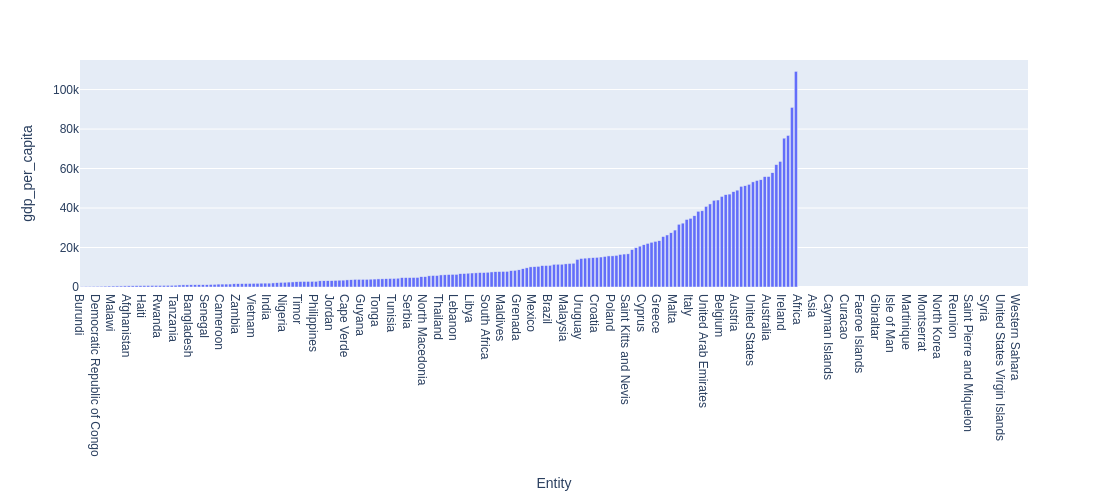

In [21]:
px.bar(gdp_and_pop_2017.sort_values("gdp_per_capita"), x="Entity", y="gdp_per_capita", height=500, width=600)

In [22]:
gdp_and_pop = pd.merge(left=gdp, right=pop, left_on="Entity", right_on="Entity", how="inner")
gdp_and_pop

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population
0,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,1800,3280000
1,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,1801,3280000
2,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,1802,3280000
3,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,1803,3280000
4,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,1804,3280000
...,...,...,...,...,...,...,...,...
1904165,Zimbabwe,ZWE,2017,1.532981e+10,15.329811,ZWE,2015,13815000
1904166,Zimbabwe,ZWE,2017,1.532981e+10,15.329811,ZWE,2016,14030000
1904167,Zimbabwe,ZWE,2017,1.532981e+10,15.329811,ZWE,2017,14237000
1904168,Zimbabwe,ZWE,2017,1.532981e+10,15.329811,ZWE,2018,14439000


In [23]:
gdp_and_pop.query("Entity == 'Afghanistan'")

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population
0,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,1800,3280000
1,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,1801,3280000
2,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,1802,3280000
3,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,1803,3280000
4,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,1804,3280000
...,...,...,...,...,...,...,...,...
3515,Afghanistan,AFG,2017,2.196941e+10,21.969414,AFG,2015,34414000
3516,Afghanistan,AFG,2017,2.196941e+10,21.969414,AFG,2016,35383000
3517,Afghanistan,AFG,2017,2.196941e+10,21.969414,AFG,2017,36296000
3518,Afghanistan,AFG,2017,2.196941e+10,21.969414,AFG,2018,37172000


In [24]:
gdp.query("Entity == 'Afghanistan'")

,Entity,Code,Year,GDP (constant 2010 US$),gdp
0,Afghanistan,AFG,2002,8.013233e+09,8.013233
1,Afghanistan,AFG,2003,8.689884e+09,8.689884
2,Afghanistan,AFG,2004,8.781610e+09,8.781610
3,Afghanistan,AFG,2005,9.762979e+09,9.762979
4,Afghanistan,AFG,2006,1.030523e+10,10.305228
...,...,...,...,...,...
11,Afghanistan,AFG,2013,2.010705e+10,20.107051
12,Afghanistan,AFG,2014,2.064804e+10,20.648036
13,Afghanistan,AFG,2015,2.091853e+10,20.918533
14,Afghanistan,AFG,2016,2.141361e+10,21.413615


In [25]:
pop.query("Entity == 'Afghanistan'")

,Entity,Code,Year,population
0,Afghanistan,AFG,1800,3280000
1,Afghanistan,AFG,1801,3280000
2,Afghanistan,AFG,1802,3280000
3,Afghanistan,AFG,1803,3280000
4,Afghanistan,AFG,1804,3280000
...,...,...,...,...
215,Afghanistan,AFG,2015,34414000
216,Afghanistan,AFG,2016,35383000
217,Afghanistan,AFG,2017,36296000
218,Afghanistan,AFG,2018,37172000


In [26]:
220 * 16 # all possible combination ... duplicates

3520

In [27]:
gdp_and_pop = pd.merge(left=gdp, right=pop, left_on=["Entity", "Year"], right_on=["Entity", "Year"], how="left")
gdp_and_pop

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population
0,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,22601000.0
1,Afghanistan,AFG,2003,8.689884e+09,8.689884,AFG,23681000.0
2,Afghanistan,AFG,2004,8.781610e+09,8.781610,AFG,24727000.0
3,Afghanistan,AFG,2005,9.762979e+09,9.762979,AFG,25654000.0
4,Afghanistan,AFG,2006,1.030523e+10,10.305228,AFG,26433000.0
...,...,...,...,...,...,...,...
8864,Zimbabwe,ZWE,2013,1.418193e+10,14.181927,ZWE,13350000.0
8865,Zimbabwe,ZWE,2014,1.448359e+10,14.483588,ZWE,13587000.0
8866,Zimbabwe,ZWE,2015,1.472830e+10,14.728302,ZWE,13815000.0
8867,Zimbabwe,ZWE,2016,1.481899e+10,14.818986,ZWE,14030000.0


In [28]:
gdp_and_pop["gdp_per_capita"] = gdp_and_pop["GDP (constant 2010 US$)"]/gdp_and_pop["population"]

In [29]:
gdp_and_pop["gdp_per_capita"]

0        354.552149
1        366.955940
2        355.142564
3        380.563610
4        389.862222
           ...     
8864    1062.316603
8865    1065.988675
8866    1066.109450
8867    1056.235654
8868    1076.758501
Name: gdp_per_capita, Length: 8869, dtype: float64

In [30]:
gdp_and_pop

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita
0,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,22601000.0,354.552149
1,Afghanistan,AFG,2003,8.689884e+09,8.689884,AFG,23681000.0,366.955940
2,Afghanistan,AFG,2004,8.781610e+09,8.781610,AFG,24727000.0,355.142564
3,Afghanistan,AFG,2005,9.762979e+09,9.762979,AFG,25654000.0,380.563610
4,Afghanistan,AFG,2006,1.030523e+10,10.305228,AFG,26433000.0,389.862222
...,...,...,...,...,...,...,...,...
8864,Zimbabwe,ZWE,2013,1.418193e+10,14.181927,ZWE,13350000.0,1062.316603
8865,Zimbabwe,ZWE,2014,1.448359e+10,14.483588,ZWE,13587000.0,1065.988675
8866,Zimbabwe,ZWE,2015,1.472830e+10,14.728302,ZWE,13815000.0,1066.109450
8867,Zimbabwe,ZWE,2016,1.481899e+10,14.818986,ZWE,14030000.0,1056.235654


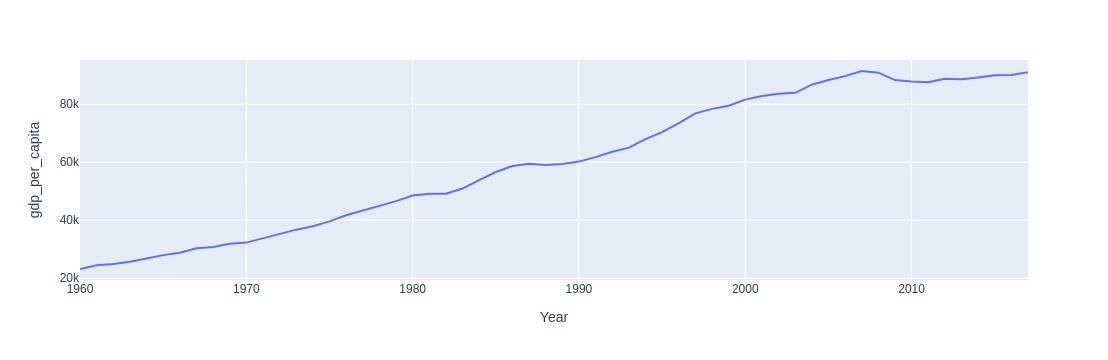

In [31]:
px.line(gdp_and_pop.query('Entity == "Norway"'), x="Year", y = "gdp_per_capita")

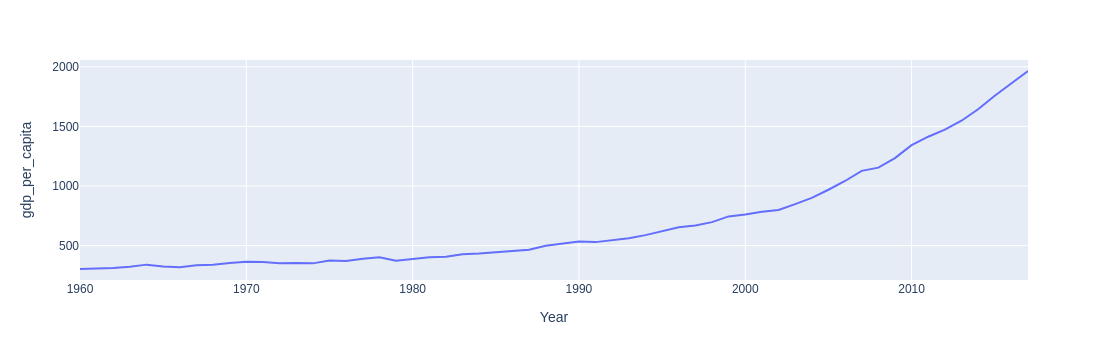

In [32]:
px.line(gdp_and_pop.query('Entity == "India"'), x="Year", y = "gdp_per_capita")

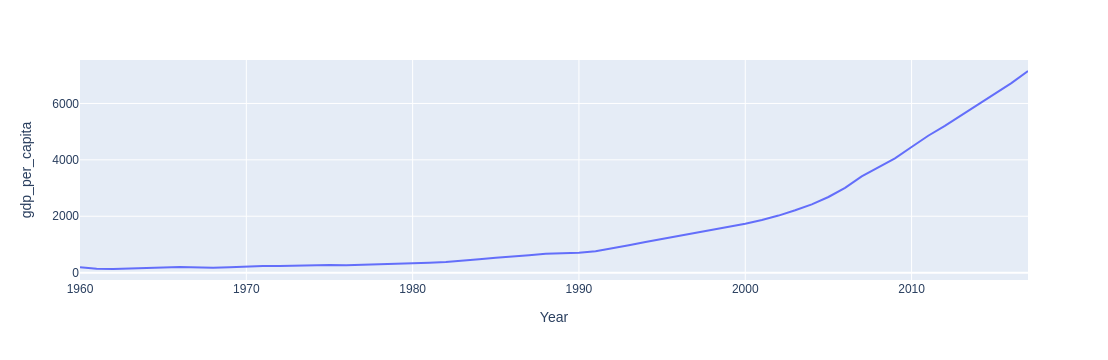

In [33]:
px.line(gdp_and_pop.query('Entity == "China"'), x="Year", y = "gdp_per_capita")

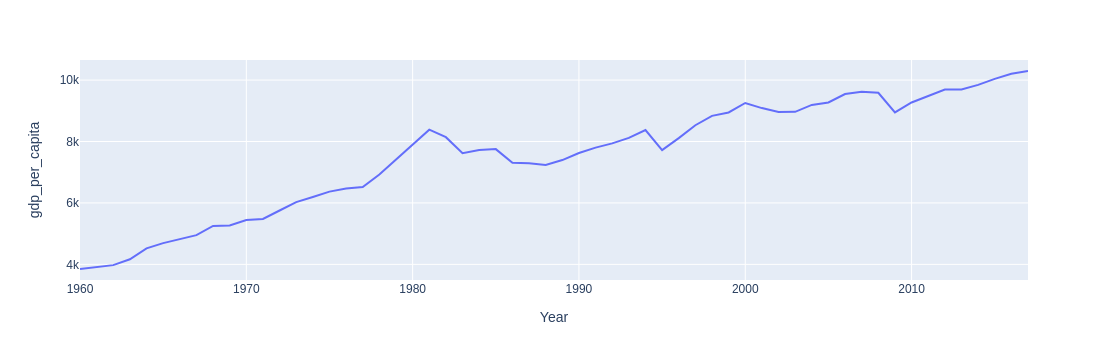

In [34]:
px.line(gdp_and_pop.query('Entity == "Mexico"'), x="Year", y = "gdp_per_capita")

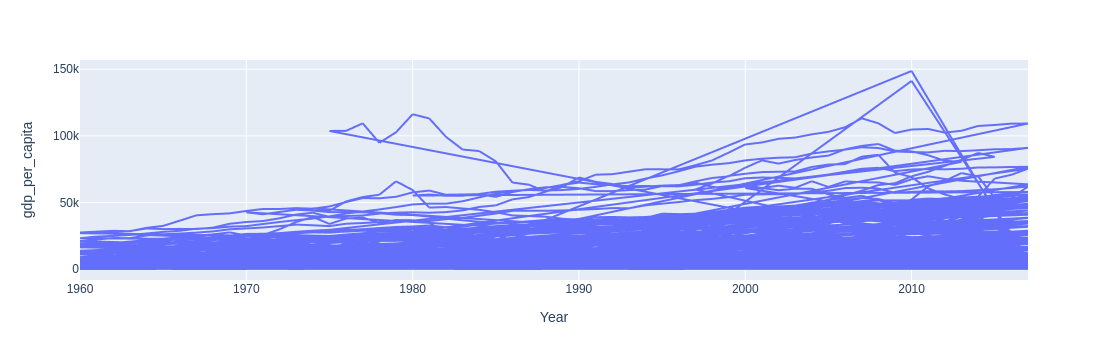

In [35]:
px.line(gdp_and_pop, x="Year", y = "gdp_per_capita")

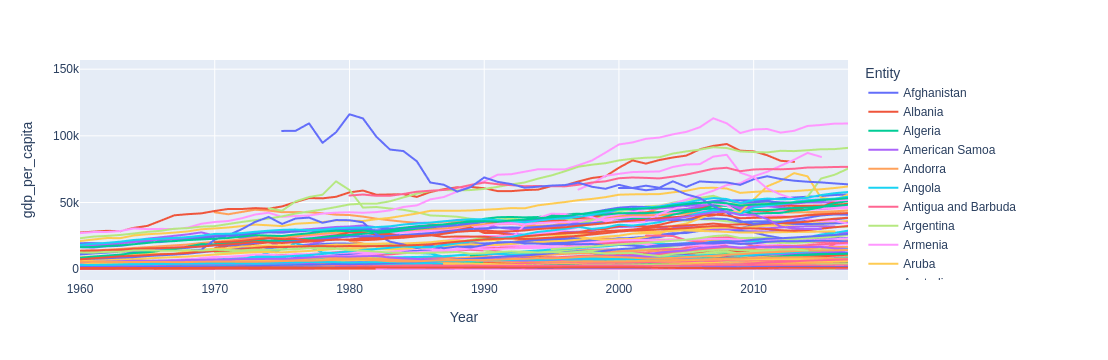

In [36]:
px.line(gdp_and_pop, x="Year", y = "gdp_per_capita", color="Entity")

In [37]:
gdp_and_pop_by_entity = gdp_and_pop.set_index("Entity")


In [38]:
gdp_and_pop_by_entity.head(3)

,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita
Entity,,,,,,,
Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,22601000.0,354.552149
Afghanistan,AFG,2003,8.689884e+09,8.689884,AFG,23681000.0,366.955940
Afghanistan,AFG,2004,8.781610e+09,8.781610,AFG,24727000.0,355.142564


In [39]:
gdp_per_capitas_160 = gdp_and_pop_by_entity.query("Year == 1960")[["gdp_per_capita"]]
type(gdp_per_capitas_160)

pandas.DataFrame

In [40]:
gdp_and_pop_by_entity["gdp_per_cap_ratio"] = gdp_and_pop_by_entity["gdp_per_capita"] / gdp_per_capitas_160["gdp_per_capita"]

In [41]:
gdp_and_pop_by_entity

,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio
Entity,,,,,,,,
Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,22601000.0,354.552149,NaN
Afghanistan,AFG,2003,8.689884e+09,8.689884,AFG,23681000.0,366.955940,NaN
Afghanistan,AFG,2004,8.781610e+09,8.781610,AFG,24727000.0,355.142564,NaN
Afghanistan,AFG,2005,9.762979e+09,9.762979,AFG,25654000.0,380.563610,NaN
Afghanistan,AFG,2006,1.030523e+10,10.305228,AFG,26433000.0,389.862222,NaN
...,...,...,...,...,...,...,...,...
Zimbabwe,ZWE,2013,1.418193e+10,14.181927,ZWE,13350000.0,1062.316603,1.192968
Zimbabwe,ZWE,2014,1.448359e+10,14.483588,ZWE,13587000.0,1065.988675,1.197091
Zimbabwe,ZWE,2015,1.472830e+10,14.728302,ZWE,13815000.0,1066.109450,1.197227


In [42]:
gdp_and_pop = gdp_and_pop_by_entity.reset_index()
gdp_and_pop

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio
0,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,22601000.0,354.552149,NaN
1,Afghanistan,AFG,2003,8.689884e+09,8.689884,AFG,23681000.0,366.955940,NaN
2,Afghanistan,AFG,2004,8.781610e+09,8.781610,AFG,24727000.0,355.142564,NaN
3,Afghanistan,AFG,2005,9.762979e+09,9.762979,AFG,25654000.0,380.563610,NaN
4,Afghanistan,AFG,2006,1.030523e+10,10.305228,AFG,26433000.0,389.862222,NaN
...,...,...,...,...,...,...,...,...,...
8864,Zimbabwe,ZWE,2013,1.418193e+10,14.181927,ZWE,13350000.0,1062.316603,1.192968
8865,Zimbabwe,ZWE,2014,1.448359e+10,14.483588,ZWE,13587000.0,1065.988675,1.197091
8866,Zimbabwe,ZWE,2015,1.472830e+10,14.728302,ZWE,13815000.0,1066.109450,1.197227
8867,Zimbabwe,ZWE,2016,1.481899e+10,14.818986,ZWE,14030000.0,1056.235654,1.186139


In [43]:
gdp_per_cap_ratio_history = gdp_and_pop.dropna()

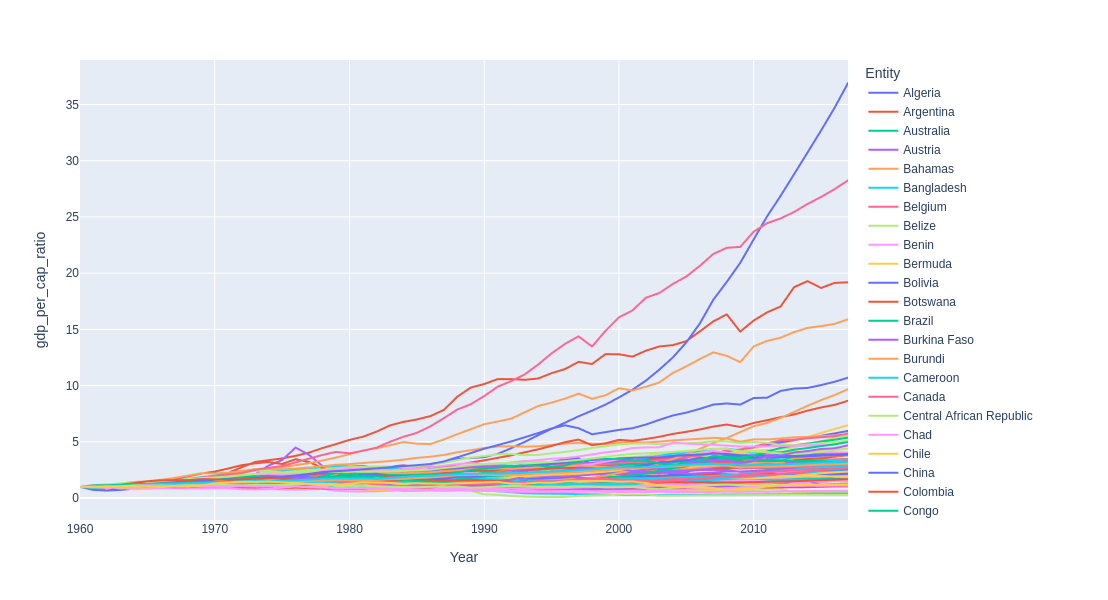

In [44]:
px.line(gdp_per_cap_ratio_history, x = "Year", y = "gdp_per_cap_ratio", color = "Entity", height=600)

In [45]:
gdp_and_pop_entity = gdp_per_cap_ratio_history.set_index("Entity")

In [46]:
gdp_and_pop_by_entity = gdp_per_cap_ratio_history.set_index("Entity")
gdp_and_pop_by_entity["pop_ratio"] = gdp_and_pop_by_entity["population"] / gdp_and_pop_by_entity.query("Year == 1960")["population"]
gdp_and_pop_by_entity["gdp_ratio"] = gdp_and_pop_by_entity["gdp"] / gdp_and_pop_by_entity.query("Year == 1960")["gdp"]
gdp_and_pop = gdp_and_pop_by_entity.reset_index()

In [47]:
gdp_and_pop

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio,pop_ratio,gdp_ratio
0,Algeria,DZA,1960,2.743440e+10,27.434399,DZA,11058000.0,2480.954892,1.000000,1.000000,1.000000
1,Algeria,DZA,1961,2.370183e+10,23.701828,DZA,11336000.0,2090.845811,0.842758,1.025140,0.863946
2,Algeria,DZA,1962,1.903611e+10,19.036113,DZA,11620000.0,1638.219736,0.660318,1.050823,0.693878
3,Algeria,DZA,1963,2.556811e+10,25.568114,DZA,11913000.0,2146.236350,0.865085,1.077320,0.931973
4,Algeria,DZA,1964,2.706114e+10,27.061141,DZA,12222000.0,2214.133643,0.892452,1.105263,0.986395
...,...,...,...,...,...,...,...,...,...,...,...
5207,Zimbabwe,ZWE,2013,1.418193e+10,14.181927,ZWE,13350000.0,1062.316603,1.192968,3.534551,4.216605
5208,Zimbabwe,ZWE,2014,1.448359e+10,14.483588,ZWE,13587000.0,1065.988675,1.197091,3.597299,4.306296
5209,Zimbabwe,ZWE,2015,1.472830e+10,14.728302,ZWE,13815000.0,1066.109450,1.197227,3.657665,4.379055
5210,Zimbabwe,ZWE,2016,1.481899e+10,14.818986,ZWE,14030000.0,1056.235654,1.186139,3.714588,4.406017


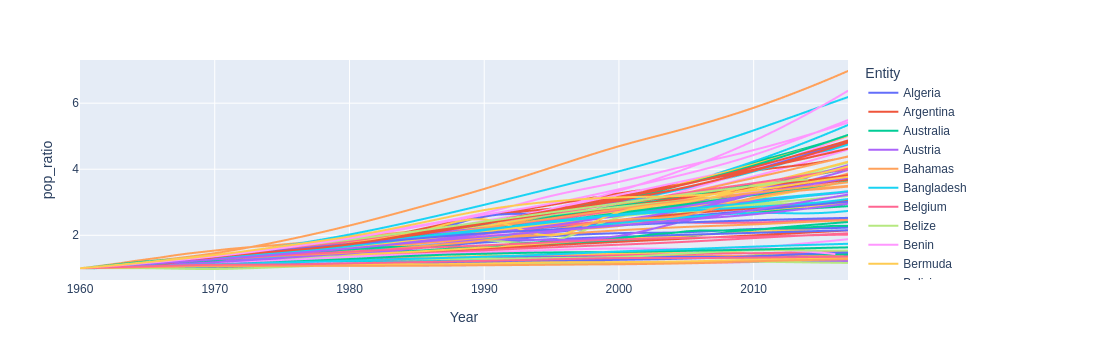

In [48]:
px.line(gdp_and_pop, x = "Year", y = "pop_ratio", color = "Entity")

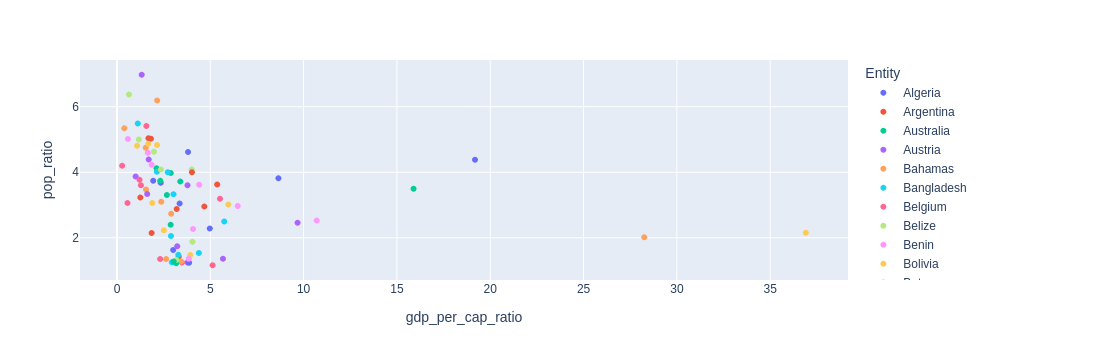

In [49]:
px.scatter(gdp_and_pop.query("Year == 2017"), x = "gdp_per_cap_ratio", y = "pop_ratio", color = "Entity", width=700)

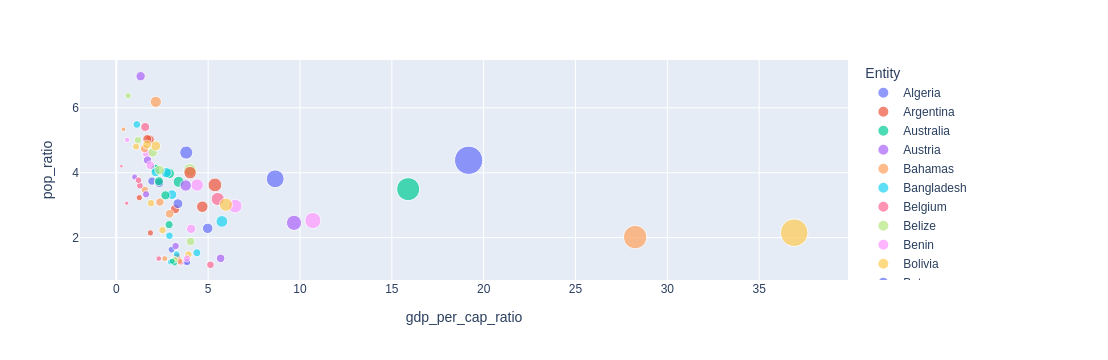

In [50]:
px.scatter(gdp_and_pop.query("Year == 2017"), x = "gdp_per_cap_ratio", y = "pop_ratio", color = "Entity", size = "gdp_ratio")

In [51]:
life_exp = pd.read_csv("../data/life_expectancy.csv")
life_exp

,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,1950,27.638
1,Afghanistan,AFG,1951,27.878
2,Afghanistan,AFG,1952,28.361
3,Afghanistan,AFG,1953,28.852
4,Afghanistan,AFG,1954,29.350
...,...,...,...,...
18440,Zimbabwe,ZWE,2015,59.534
18441,Zimbabwe,ZWE,2016,60.294
18442,Zimbabwe,ZWE,2017,60.812
18443,Zimbabwe,ZWE,2018,61.195


In [52]:
life_exp = life_exp[["Entity", "Year", "Life expectancy"]]

In [53]:
gdp_pop_le = pd.merge(left = gdp_and_pop, right = life_exp, left_on = ["Entity", "Year"], right_on = ["Entity", "Year"], how = "left")

In [54]:
gdp_pop_le

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio,pop_ratio,gdp_ratio,Life expectancy
0,Algeria,DZA,1960,2.743440e+10,27.434399,DZA,11058000.0,2480.954892,1.000000,1.000000,1.000000,46.141
1,Algeria,DZA,1961,2.370183e+10,23.701828,DZA,11336000.0,2090.845811,0.842758,1.025140,0.863946,46.599
2,Algeria,DZA,1962,1.903611e+10,19.036113,DZA,11620000.0,1638.219736,0.660318,1.050823,0.693878,47.056
3,Algeria,DZA,1963,2.556811e+10,25.568114,DZA,11913000.0,2146.236350,0.865085,1.077320,0.931973,47.509
4,Algeria,DZA,1964,2.706114e+10,27.061141,DZA,12222000.0,2214.133643,0.892452,1.105263,0.986395,47.958
...,...,...,...,...,...,...,...,...,...,...,...,...
5207,Zimbabwe,ZWE,2013,1.418193e+10,14.181927,ZWE,13350000.0,1062.316603,1.192968,3.534551,4.216605,56.897
5208,Zimbabwe,ZWE,2014,1.448359e+10,14.483588,ZWE,13587000.0,1065.988675,1.197091,3.597299,4.306296,58.410
5209,Zimbabwe,ZWE,2015,1.472830e+10,14.728302,ZWE,13815000.0,1066.109450,1.197227,3.657665,4.379055,59.534
5210,Zimbabwe,ZWE,2016,1.481899e+10,14.818986,ZWE,14030000.0,1056.235654,1.186139,3.714588,4.406017,60.294


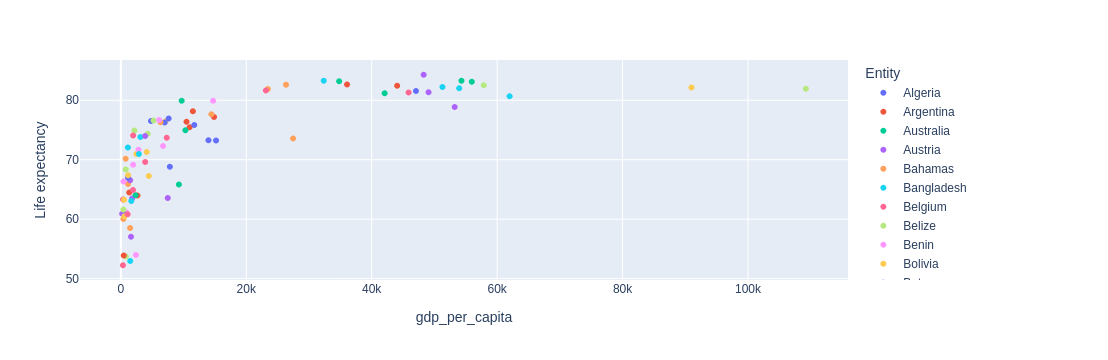

In [55]:
px.scatter(gdp_pop_le.query("Year == 2017"), x = "gdp_per_capita", 
           y = "Life expectancy", color = "Entity")

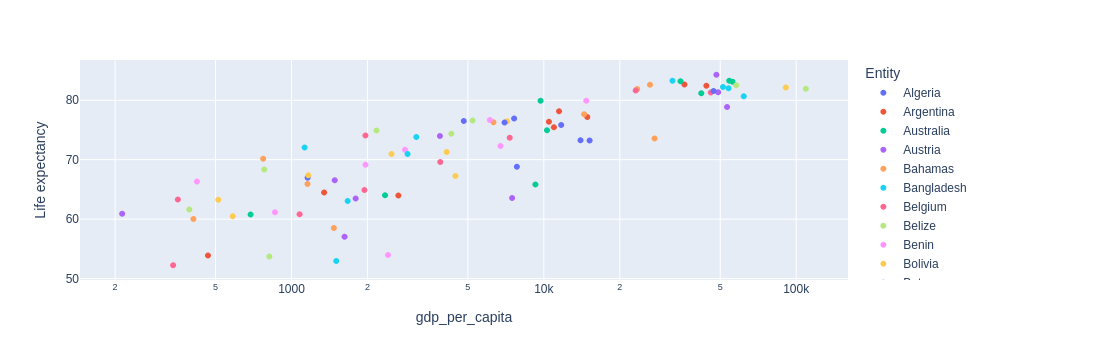

In [56]:
px.scatter(gdp_pop_le.query("Year == 2017"), x = "gdp_per_capita", 
           y = "Life expectancy", color = "Entity", log_x = True)

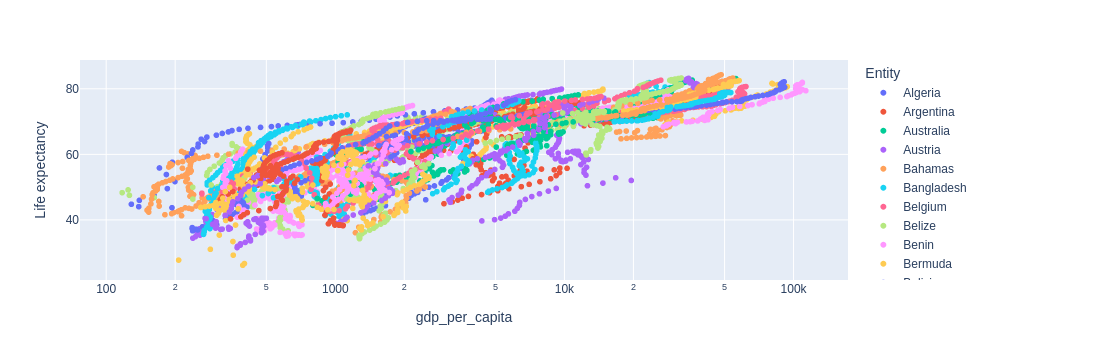

In [57]:
px.scatter(gdp_pop_le, x = "gdp_per_capita", 
           y = "Life expectancy", color = "Entity", log_x = True)

In [58]:
gdp_pop_le[gdp_pop_le["Entity"].str.contains("in")]

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio,pop_ratio,gdp_ratio,Life expectancy
58,Argentina,ARG,1960,1.155739e+11,115.573869,ARG,20482000.0,5642.704253,1.000000,1.000000,1.000000,65.055
59,Argentina,ARG,1961,1.218470e+11,121.847037,ARG,20817000.0,5853.246697,1.037312,1.016356,1.054278,65.176
60,Argentina,ARG,1962,1.208089e+11,120.808874,ARG,21153000.0,5711.193378,1.012138,1.032760,1.045296,65.269
61,Argentina,ARG,1963,1.143961e+11,114.396101,ARG,21489000.0,5323.472508,0.943426,1.049165,0.989809,65.348
62,Argentina,ARG,1964,1.259848e+11,125.984766,ARG,21824000.0,5772.762383,1.023049,1.065521,1.090080,65.426
...,...,...,...,...,...,...,...,...,...,...,...,...
4920,United Kingdom,GBR,2013,2.564905e+12,2564.904713,GBR,64984000.0,39469.788151,2.852872,1.240839,3.539956,80.876
4921,United Kingdom,GBR,2014,2.643243e+12,2643.243341,GBR,65423000.0,40402.356073,2.920278,1.249222,3.648075,80.978
4922,United Kingdom,GBR,2015,2.705252e+12,2705.252231,GBR,65860000.0,41075.800659,2.968954,1.257566,3.733657,81.052
4923,United Kingdom,GBR,2016,2.757620e+12,2757.620259,GBR,66298000.0,41594.320481,3.006433,1.265930,3.805933,81.111


In [59]:
gdp_pop_le[gdp_pop_le["Entity"].str.startswith("B")]

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio,pop_ratio,gdp_ratio,Life expectancy
232,Bahamas,BHS,1960,1.942538e+09,1.942538,BHS,110000.0,17659.437251,1.000000,1.000000,1.000000,64.740
233,Bahamas,BHS,1961,2.149751e+09,2.149751,BHS,115000.0,18693.482862,1.058555,1.045455,1.106671,64.885
234,Bahamas,BHS,1962,2.374442e+09,2.374442,BHS,121000.0,19623.486365,1.111218,1.100000,1.222340,65.011
235,Bahamas,BHS,1963,2.624329e+09,2.624329,BHS,127000.0,20664.011191,1.170140,1.154545,1.350980,65.121
236,Bahamas,BHS,1964,2.899925e+09,2.899925,BHS,134000.0,21641.232380,1.225477,1.218182,1.492854,65.219
...,...,...,...,...,...,...,...,...,...,...,...,...
861,Burundi,BDI,2013,2.297623e+09,2.297623,BDI,9540000.0,240.840958,1.129507,3.409578,3.851141,59.148
862,Burundi,BDI,2014,2.404713e+09,2.404713,BDI,9844000.0,244.282107,1.145645,3.518227,4.030640,59.665
863,Burundi,BDI,2015,2.310421e+09,2.310421,BDI,10160000.0,227.403625,1.066488,3.631165,3.872593,60.123
864,Burundi,BDI,2016,2.297241e+09,2.297241,BDI,10488000.0,219.035220,1.027241,3.748392,3.850502,60.528


In [60]:
gdp_pop_le["Entity"].str.upper()

0        ALGERIA
1        ALGERIA
2        ALGERIA
3        ALGERIA
4        ALGERIA
          ...   
5207    ZIMBABWE
5208    ZIMBABWE
5209    ZIMBABWE
5210    ZIMBABWE
5211    ZIMBABWE
Name: Entity, Length: 5212, dtype: str

In [62]:
gdp_pop_le[gdp_pop_le["Entity"].str.contains(" ")]

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio,pop_ratio,gdp_ratio,Life expectancy
750,Burkina Faso,BFA,1960,1.153497e+09,1.153497,BFA,4829000.0,238.868808,1.000000,1.000000,1.000000,34.432
751,Burkina Faso,BFA,1961,1.200144e+09,1.200144,BFA,4895000.0,245.177544,1.026411,1.013667,1.040439,34.897
752,Burkina Faso,BFA,1962,1.273698e+09,1.273698,BFA,4960000.0,256.794051,1.075042,1.027128,1.104206,35.369
753,Burkina Faso,BFA,1963,1.257548e+09,1.257548,BFA,5028000.0,250.108948,1.047056,1.041209,1.090204,35.847
754,Burkina Faso,BFA,1964,1.286255e+09,1.286255,BFA,5099000.0,252.256390,1.056046,1.055912,1.115092,36.331
...,...,...,...,...,...,...,...,...,...,...,...,...
4978,United States,USA,2013,1.580286e+13,15802.855301,USA,316400992.0,49945.656622,3.029788,1.694512,5.134012,78.909
4979,United States,USA,2014,1.620886e+13,16208.861247,USA,318672992.0,50863.617735,3.085473,1.706680,5.265915,78.922
4980,United States,USA,2015,1.667269e+13,16672.691918,USA,320878016.0,51959.595505,3.151957,1.718489,5.416604,78.910
4981,United States,USA,2016,1.692033e+13,16920.327942,USA,323016000.0,52382.321439,3.177600,1.729939,5.497056,78.885


### New Features --- Tricky

In [63]:
# convert wiki table to csv
# wiki 
!dir ../data

allvisits.csv	      continents.csv  housing.csv	 life_expectancy.csv
cell_phone_churn.csv  gdp.csv	      indian_states.csv  population.csv


In [64]:
df = pd.read_csv("../data/indian_states.csv") # from wiki

In [65]:
df

,State,ISO 3166-2:IN,Vehiclecode,Zone,Capital,Largest city,Statehood,Population(census 2011)[citation needed],Area(km2),Officiallanguages[39],Additional officiallanguages[39]
0,Andhra Pradesh,IN-AP,AP,Southern,Visakhapatnam (Administrative)[40]Amaravati (L...,Visakhapatnam,1 November 1956,"49,506,799","160,205",Telugu,—
1,Arunachal Pradesh,IN-AR,AR,North-Eastern,Itanagar,Itanagar,20 February 1987,"1,383,727","83,743",English,—
2,Assam,IN-AS,AS,North-Eastern,Dispur,Guwahati,26 January 1950,"31,205,576","78,550",Assamese,"Bengali, Bodo"
3,Bihar,IN-BR,BR,Eastern,Patna,Patna,26 January 1950,"104,099,452","94,163",Hindi,Urdu
4,Chhattisgarh,IN-CT,CG,Central,Nava Raipur,Raipur,1 November 2000,"25,545,198","135,194",Hindi,Chhattisgarhi
...,...,...,...,...,...,...,...,...,...,...,...
23,Telangana,IN-TG,TS,Southern,Hyderabad[b],Hyderabad[b],2 June 2014,"35,193,978[48]","114,840[48]",Telugu,Urdu[49]
24,Tripura,IN-TR,TR,North-Eastern,Agartala,Agartala,21 January 1972,"3,673,917","10,492","Bengali, English, Kokborok",—
25,Uttar Pradesh,IN-UP,UP,Central,Lucknow,Kanpur,26 January 1950,"199,812,341","243,286",Hindi,Urdu
26,Uttarakhand,IN-UT,UK,Central,Gairsain (Summer)Dehradun (Winter)[50],Dehradun,9 November 2000,"10,086,292","53,483",Hindi,Sanskrit[51]


In [82]:
df = df.rename(columns = {"Officiallanguages[39]": "official",
                          "Additional officiallanguages[39]": "other",
                          "Population(census 2011)[citation needed]": "population"})

In [67]:
df.head()

,State,ISO 3166-2:IN,Vehiclecode,Zone,Capital,Largest city,Statehood,population,Area(km2),official,other
0,Andhra Pradesh,IN-AP,AP,Southern,Visakhapatnam (Administrative)[40]Amaravati (L...,Visakhapatnam,1 November 1956,"49,506,799","160,205",Telugu,—
1,Arunachal Pradesh,IN-AR,AR,North-Eastern,Itanagar,Itanagar,20 February 1987,"1,383,727","83,743",English,—
2,Assam,IN-AS,AS,North-Eastern,Dispur,Guwahati,26 January 1950,"31,205,576","78,550",Assamese,"Bengali, Bodo"
3,Bihar,IN-BR,BR,Eastern,Patna,Patna,26 January 1950,"104,099,452","94,163",Hindi,Urdu
4,Chhattisgarh,IN-CT,CG,Central,Nava Raipur,Raipur,1 November 2000,"25,545,198","135,194",Hindi,Chhattisgarhi


In [83]:
telugu_states = df[(df["other"].str.contains("Telugu")) | (df["official"].str.contains("Telugu"))]
telugu_states

,State,ISO 3166-2:IN,Vehiclecode,Zone,Capital,Largest city,Statehood,population,Area(km2),official,other
0,Andhra Pradesh,IN-AP,AP,Southern,Visakhapatnam (Administrative)[40]Amaravati (L...,Visakhapatnam,1 November 1956,49506799,"160,205",Telugu,—
23,Telangana,IN-TG,TS,Southern,Hyderabad[b],Hyderabad[b],2 June 2014,35193978[48],"114,840[48]",Telugu,Urdu[49]
27,West Bengal,IN-WB,WB,Eastern,Kolkata,Kolkata,26 January 1950,91276115,"88,752","Bengali, Nepali[c]","Hindi, Odia, Telugu, Punjabi, Santali, Urdu"


In [86]:
try:
    sum(telugu_states["population"])
except Exception as e:
    print(e)
    

unsupported operand type(s) for +: 'int' and 'str'


In [70]:
(telugu_states["population"]).count()

np.int64(3)

In [72]:
len(telugu_states["population"])

3

In [73]:
telugu_states["population"].sum() # string concatenation

'49,506,79935,193,978[48]91,276,115'

In [74]:
telugu_states.dtypes

State            str
ISO 3166-2:IN    str
Vehiclecode      str
Zone             str
Capital          str
                ... 
Statehood        str
population       str
Area(km2)        str
official         str
other            str
Length: 11, dtype: object

In [87]:
try:
    pd.to_numeric(df["population"]) # commas
except Exception as e:
    print(e)

Unable to parse string "35193978[48]" at position 23


In [88]:
df["population"] = df["population"].str.replace(",", "") # remove commas

In [90]:
try:
    pd.to_numeric(df["population"])
except Exception as e:
    print(e)

Unable to parse string "35193978[48]" at position 23


In [91]:
df["population"].str.replace("[48]","") # can act as a regex pattter

0      49506799
1       1383727
2      31205576
3     104099452
4      25545198
        ...    
23     35193978
24      3673917
25    199812341
26     10086292
27     91276115
Name: population, Length: 28, dtype: str

In [96]:
df["population"].str.replace(r"\[48\]","",regex=True)

0      49506799
1       1383727
2      31205576
3     104099452
4      25545198
        ...    
23     35193978
24      3673917
25    199812341
26     10086292
27     91276115
Name: population, Length: 28, dtype: str

In [94]:
#'book'.replace('o','x',2)